In [1]:
!pip install numba

In [3]:
!pip install pandas

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -

In [5]:
!pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   ----------

In [6]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl.metadata (52 kB)
Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl (8.1 MB)


In [3]:
import pandas as pd
import numpy as np
from numba import cuda
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [4]:
df = pd.read_csv("Titanic-Dataset.csv")

In [5]:
# ===== BASIC INFO =====
print("===== DATA INFO =====")
print(df.info())

print("\n===== DESCRIPTIVE STATS =====")
print(df.describe())


# ===== MISSING VALUES =====
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())


# ===== SURVIVAL DISTRIBUTION =====
print("\n===== SURVIVAL DISTRIBUTION =====")
print(df['Survived'].value_counts())


# ===== VISUALIZATION =====
import matplotlib.pyplot as plt
import seaborn as sns

# Survival count
sns.countplot(x='Survived', data=df)
plt.title("Survival Distribution")
plt.show()


# Survival vs Gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()


# Survival vs Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()


# Age distribution
sns.histplot(df['Age'].dropna(), kde=True)
plt.title("Age Distribution")
plt.show()


# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

===== DATA INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

===== DESCRIPTIVE STATS =====
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   2

ModuleNotFoundError: No module named 'seaborn'

In [ ]:

# Drop irrelevant columns
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encode categorical
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])

# Split
X = df.drop('Survived', axis=1).values
y = df['Survived'].values

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to float32 (important for CUDA)
X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_test = y_test.astype(np.float32)

C:\Users\Uttkarsh Dhiman\AppData\Local\Temp\ipykernel_22608\196483924.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Uttkarsh Dhiman\AppData\Local\Temp\ipykernel_22608\196483924.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [31]:
@cuda.jit(device=True)
def sigmoid(x):
    return 1.0 / (1.0 + math.exp(-x))

In [32]:
@cuda.jit
def predict_kernel(X, weights, bias, preds):
    i = cuda.grid(1)
    
    if i < X.shape[0]:
        z = 0.0
        
        for j in range(X.shape[1]):
            z += X[i, j] * weights[j]
        
        z += bias
        
        preds[i] = 1.0 / (1.0 + math.exp(-z))

In [33]:
@cuda.jit
def gradient_kernel(X, y, weights, bias, grad_w, grad_b):
    i = cuda.grid(1)
    
    if i < X.shape[0]:
        z = 0.0
        
        for j in range(X.shape[1]):
            z += X[i, j] * weights[j]
        
        z += bias  
        
        pred = 1.0 / (1.0 + math.exp(-z))
        error = pred - y[i]
        
        for j in range(X.shape[1]):
            cuda.atomic.add(grad_w, j, error * X[i, j])
        
        cuda.atomic.add(grad_b, 0, error)

In [ ]:

n_features = X_train.shape[1]

weights = np.zeros(n_features, dtype=np.float32)
bias = np.float32(0.0)

d_X = cuda.to_device(X_train)
d_y = cuda.to_device(y_train)
d_weights = cuda.to_device(weights)

threads_per_block = 256
blocks = (X_train.shape[0] + threads_per_block - 1) // threads_per_block

lr = 0.01
epochs = 100

for epoch in range(epochs):
    
    grad_w = np.zeros(n_features, dtype=np.float32)
    grad_b = np.zeros(1, dtype=np.float32)
    
    d_grad_w = cuda.to_device(grad_w)
    d_grad_b = cuda.to_device(grad_b)
    
    gradient_kernel[blocks, threads_per_block](
        d_X, d_y, d_weights, bias, d_grad_w, d_grad_b
    )
    
    grad_w = d_grad_w.copy_to_host()
    grad_b = d_grad_b.copy_to_host()
    
    weights -= lr * grad_w / X_train.shape[0]
    bias -= lr * grad_b[0] / X_train.shape[0]
    
    d_weights = cuda.to_device(weights)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1} complete")

d:\Python\lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Epoch 10 complete
Epoch 20 complete
Epoch 30 complete
Epoch 40 complete
Epoch 50 complete
Epoch 60 complete
Epoch 70 complete
Epoch 80 complete
Epoch 90 complete
Epoch 100 complete


In [35]:
d_X_test = cuda.to_device(X_test)

preds = np.zeros(X_test.shape[0], dtype=np.float32)
d_preds = cuda.to_device(preds)

blocks_test = (X_test.shape[0] + threads_per_block - 1) // threads_per_block

predict_kernel[blocks_test, threads_per_block](
    d_X_test, d_weights, bias, d_preds
)

preds = d_preds.copy_to_host()
pred_labels = (preds > 0.5).astype(np.float32)

d:\Python\lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


In [36]:
accuracy = np.mean(pred_labels == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.776536312849162


In [37]:
tp = np.sum((pred_labels == 1) & (y_test == 1))
tn = np.sum((pred_labels == 0) & (y_test == 0))
fp = np.sum((pred_labels == 1) & (y_test == 0))
fn = np.sum((pred_labels == 0) & (y_test == 1))

print("Confusion Matrix:")
print(f"TP: {tp}, FP: {fp}")
print(f"FN: {fn}, TN: {tn}")

Confusion Matrix:
TP: 58, FP: 24
FN: 16, TN: 81


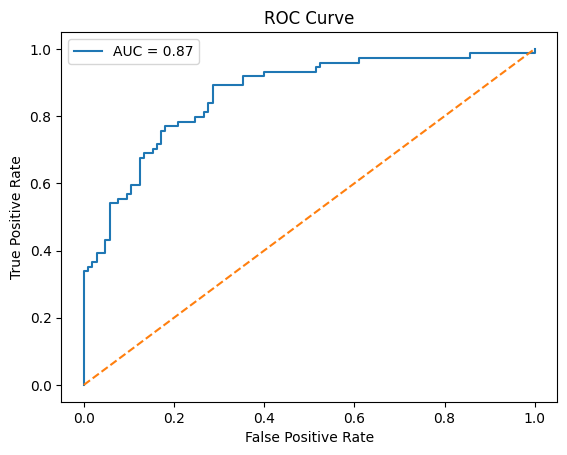

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
# ===== SAMPLE DATA =====
samples = pd.DataFrame([
    [3, 'male', 22, 1, 0, 7.25, 'S'],
    [1, 'female', 38, 1, 0, 71.28, 'C'],
    [2, 'female', 26, 0, 0, 13.00, 'S']
], columns=['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked'])

samples['Sex'] = le_sex.transform(samples['Sex'])
samples['Embarked'] = le_embarked.transform(samples['Embarked'])


# ===== SCALING =====
samples_scaled = scaler.transform(samples).astype(np.float32)


# ===== MOVE TO GPU =====
d_samples = cuda.to_device(samples_scaled)

preds = np.zeros(samples.shape[0], dtype=np.float32)
d_preds = cuda.to_device(preds)


# ===== CUDA PREDICTION =====
threads_per_block = 256
blocks = (samples.shape[0] + threads_per_block - 1) // threads_per_block

predict_kernel[blocks, threads_per_block](
    d_samples, d_weights, bias, d_preds
)


# ===== RESULTS =====
preds = d_preds.copy_to_host()

samples['Survival_Prob'] = preds
samples['Prediction'] = [
    'Survived' if p > 0.5 else 'Not Survived' for p in preds
]


print("===== PREDICTION RESULTS =====")
samples

===== PREDICTION RESULTS =====


d:\Python\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survival_Prob,Prediction
0,3,1,22,1,0,7.25,2,0.382626,Not Survived
1,1,0,38,1,0,71.28,0,0.635741,Survived
2,2,0,26,0,0,13.00,2,0.545731,Survived
